#### Import required packages

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

#### Import sample data and drop uneccessary columns

In [2]:
data_for_model = pd.read_pickle("data/abc_regression_modelling.p")
data_for_model.drop("customer_id", axis = 1, inplace = True)
print(data_for_model.columns)

Index(['distance_from_store', 'gender', 'credit_score',
       'customer_loyalty_score', 'total_sales', 'total_items',
       'transaction_count', 'product_area_count', 'average_basket_value'],
      dtype='object')


#### Shuffle Data

In [3]:
data_for_model = shuffle(data_for_model, random_state = 42)

#### Dealing with missing values

In [4]:
data_for_model.isna().sum()
data_for_model.dropna(how = "any", inplace = True)

#### Split Input variables and Output variables

In [5]:
X = data_for_model.drop(["customer_loyalty_score"], axis = 1)
y = data_for_model["customer_loyalty_score"]

#### Split out training and test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### Dealing with categorical variables

In [7]:
categorical_vars = ["gender"]

one_hot_encoder = OneHotEncoder(sparse_output = False, drop = "first")

X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop = True), X_train_encoded.reset_index(drop = True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop = True), X_test_encoded.reset_index(drop = True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [8]:
print(X_train)

     distance_from_store  credit_score  total_sales  total_items  \
0                   0.04          0.67      1191.53          216   
1                   2.04          0.64      1581.41          343   
2                   2.24          0.63      1327.51          266   
3                   1.72          0.59      2094.10          352   
4                   0.24          0.53      1133.45          180   
..                   ...           ...          ...          ...   
310                 0.37          0.61      1397.66          270   
311                 2.94          0.62      2397.63          282   
312                 2.31          0.53      1805.39          298   
313                 2.80          0.41      1524.01          278   
314                 4.47          0.74      3770.71          415   

     transaction_count  product_area_count  average_basket_value  gender_M  
0                   53                   5             22.481698       1.0  
1                   41       

#### Model Training

In [10]:
regressor = RandomForestRegressor(random_state = 42)
regressor.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Assessment

#### Predict on the test set

In [11]:
y_pred = regressor.predict(X_test)

#### Calculate R-squared

In [12]:
r_squared = r2_score(y_test, y_pred)
print(r_squared)

0.9597164697184868


#### Cross validation

In [13]:
cv = KFold(n_splits = 4, shuffle = True, random_state = 42)
cv_scores = cross_val_score(regressor, X_train, y_train, cv =cv, scoring = "r2")
cv_scores.mean()

np.float64(0.9246701529836935)

#### Calculate adjusted R-squared

In [14]:
num_data_points, num_input_vars = X_test.shape
adjusted_r_squared = 1 - (1 - r_squared) * (num_data_points - 1) / (num_data_points - num_input_vars -1)
print(adjusted_r_squared)

0.9551126376863138


#### Feature importance

In [16]:
feature_importance = pd.DataFrame(regressor.feature_importances_)
feature_names = pd.DataFrame(X.columns)
feature_importance_summary = pd.concat([feature_names,feature_importance], axis = 1)
feature_importance_summary.columns = ["input_variable","feature_importance"]
feature_importance_summary.sort_values(by = "feature_importance", inplace = True)
print(feature_importance_summary)

         input_variable  feature_importance
7  average_basket_value            0.009976
1                gender            0.010643
6    product_area_count            0.021630
4           total_items            0.025616
5     transaction_count            0.040695
3           total_sales            0.097355
2          credit_score            0.114349
0   distance_from_store            0.679737


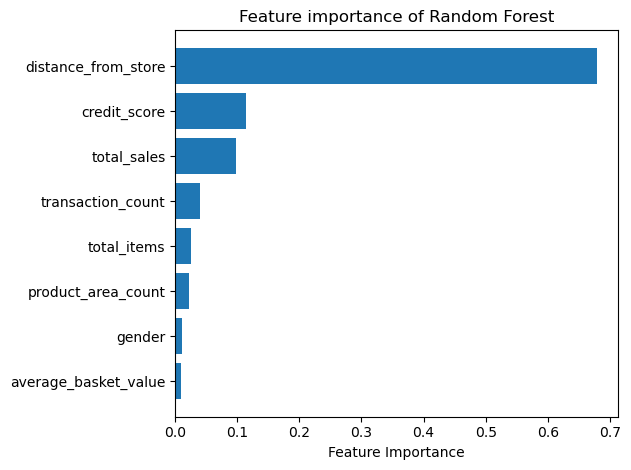

In [20]:
plt.barh(feature_importance_summary["input_variable"],feature_importance_summary["feature_importance"])
plt.title("Feature importance of Random Forest")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

#### Permutation importance

In [21]:
result = permutation_importance(regressor, X_test, y_test, n_repeats = 10, random_state = 42)

In [22]:
permutation_importance = pd.DataFrame(result["importances_mean"])
feature_names = pd.DataFrame(X.columns)
permutation_importance_summary = pd.concat([feature_names,permutation_importance], axis = 1)
permutation_importance_summary.columns = ["input_variable","permutation_importance"]
permutation_importance_summary.sort_values(by = "permutation_importance", inplace = True)

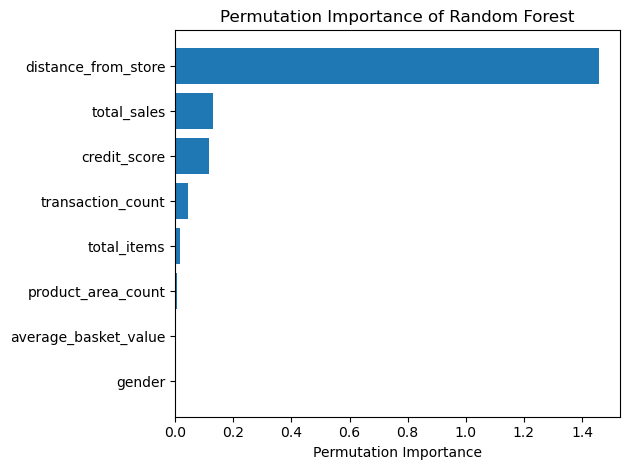

In [23]:
plt.barh(permutation_importance_summary["input_variable"], permutation_importance_summary["permutation_importance"])
plt.title("Permutation Importance of Random Forest")
plt.xlabel("Permutation Importance")
plt.tight_layout()
plt.show()

#### Predictions under the hood

In [24]:
y_pred[0]

np.float64(0.2267300000000002)

In [26]:
new_data = [X_test.iloc[0]]
regressor.estimators_

[DecisionTreeRegressor(max_features=1.0, random_state=1608637542),
 DecisionTreeRegressor(max_features=1.0, random_state=1273642419),
 DecisionTreeRegressor(max_features=1.0, random_state=1935803228),
 DecisionTreeRegressor(max_features=1.0, random_state=787846414),
 DecisionTreeRegressor(max_features=1.0, random_state=996406378),
 DecisionTreeRegressor(max_features=1.0, random_state=1201263687),
 DecisionTreeRegressor(max_features=1.0, random_state=423734972),
 DecisionTreeRegressor(max_features=1.0, random_state=415968276),
 DecisionTreeRegressor(max_features=1.0, random_state=670094950),
 DecisionTreeRegressor(max_features=1.0, random_state=1914837113),
 DecisionTreeRegressor(max_features=1.0, random_state=669991378),
 DecisionTreeRegressor(max_features=1.0, random_state=429389014),
 DecisionTreeRegressor(max_features=1.0, random_state=249467210),
 DecisionTreeRegressor(max_features=1.0, random_state=1972458954),
 DecisionTreeRegressor(max_features=1.0, random_state=1572714583),
 De

In [27]:
predictions = []
tree_count = 0
for tree in regressor.estimators_:
    prediction = tree.predict(new_data)[0]
    predictions.append(prediction)
    tree_count += 1 

print(predictions)

[np.float64(0.201), np.float64(0.668), np.float64(0.117), np.float64(0.17), np.float64(0.203), np.float64(0.268), np.float64(0.17), np.float64(0.203), np.float64(0.23400000000000004), np.float64(0.17), np.float64(0.234), np.float64(0.12), np.float64(0.234), np.float64(0.174), np.float64(0.147), np.float64(0.352), np.float64(0.268), np.float64(0.234), np.float64(0.234), np.float64(0.234), np.float64(0.203), np.float64(0.17400000000000002), np.float64(0.17), np.float64(0.234), np.float64(0.177), np.float64(0.12), np.float64(0.314), np.float64(0.174), np.float64(0.234), np.float64(0.302), np.float64(0.352), np.float64(0.314), np.float64(0.234), np.float64(0.174), np.float64(0.116), np.float64(0.221), np.float64(0.201), np.float64(0.177), np.float64(0.203), np.float64(0.147), np.float64(0.12), np.float64(0.234), np.float64(0.234), np.float64(0.201), np.float64(0.203), np.float64(0.221), np.float64(0.203), np.float64(0.366), np.float64(0.201), np.float64(0.334), np.float64(0.366), np.float6

In [29]:
sum(predictions) / tree_count

np.float64(0.2267300000000002)

In [30]:
import pickle

In [31]:
pickle.dump(regressor, open("data/random_forest_regression_model.p", "wb"))
pickle.dump(one_hot_encoder, open("data/random_forest_regression_ohe.p", "wb"))